Loading cached raw data from /home/solidburak/Documents/Codes/Python/Thesis/data/raw/master_raw_data.parquet...
Engineering stationary features...
Stationary transformation complete. Raw columns purged.
Generating ML-safe expanding GARCH features (This may take a minute)...
Masking the first 252 days of GARCH outputs for stability...
Generating rolling regimes and smoothed targets...
Target generation complete.
Generating lag features for: [1, 2, 3, 5, 10] days...
Preparing data. Target variable: Target_Smooth_10d
Training Samples: 4772 | Testing Samples: 1194
Training XGBoost Classifier...



Model Evaluation on Unseen Test Data (Chronological)
                    precision    recall  f1-score   support

    Class 0 (Calm)       0.94      0.80      0.86      1006
Class 1 (Elevated)       0.23      0.45      0.30        94
   Class 2 (Shock)       0.43      0.69      0.53        94

          accuracy                           0.77      1194
         macro avg       0.53      0.65      0.57      1194
      weighted avg       0.84      0.77      0.79      1194



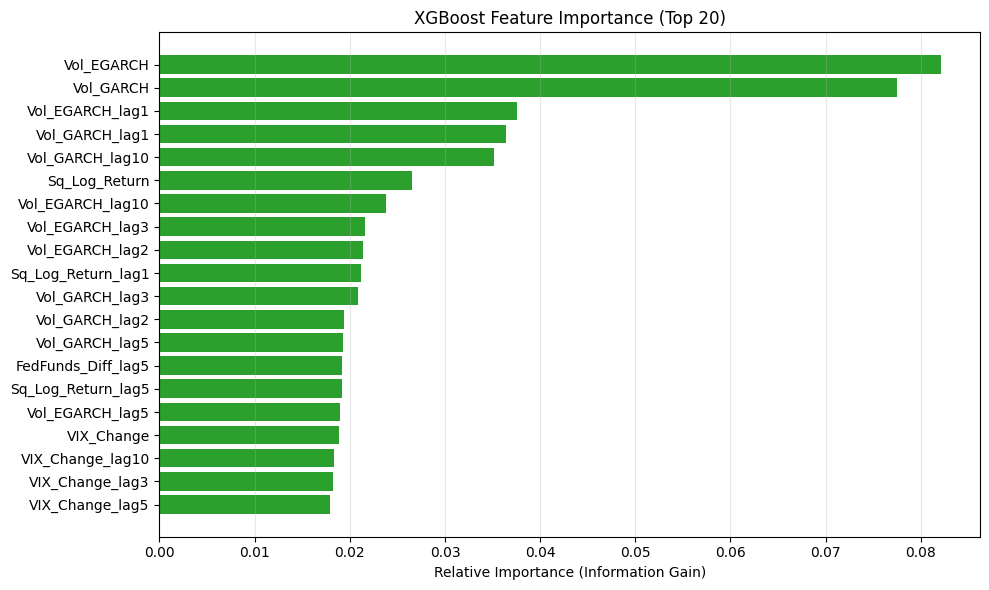

In [1]:
# 03_baseline_xgboost.ipynb

# 1. Imports
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import data_loader, features, volatility, regimes, models_xgb

# 2. The Complete Modular Pipeline Execution
raw_df = data_loader.fetch_raw_data()
stat_df = features.engineer_stationary_features(raw_df)

# Generate ML-Safe GARCH
garch_df = volatility.generate_expanding_garch(stat_df, min_obs=252)

# Generate Targets
regime_df = regimes.generate_smoothed_targets(
    garch_df, lower_quant=0.85, upper_quant=0.95, floor=0.0
)

# Generate Lags for XGBoost
cols_to_lag = [
    'Log_Return', 'Sq_Log_Return', 'Vol_GARCH', 'Vol_EGARCH', 
    'VIX_Change', 'Oil_Change', 'CPI_MoM', 'FedFunds_Diff', 'Term_Spread_Diff'
]
final_df = features.create_lags(regime_df, feature_cols=cols_to_lag)

# 3. Train and Evaluate
model, feature_names, X_test, y_test = models_xgb.train_xgboost_baseline(final_df)

# 4. Feature Importance
models_xgb.plot_feature_importance(model, feature_names)

==================================================
Model Evaluation on Unseen Test Data (Chronological)
==================================================
                    precision    recall  f1-score   support

    Class 0 (Calm)       0.95      0.81      0.88      1037
Class 1 (Elevated)       0.16      0.40      0.23        63
   Class 2 (Shock)       0.43      0.70      0.53        94

          accuracy                           0.78      1194
         macro avg       0.51      0.64      0.55      1194
      weighted avg       0.87      0.78      0.82      1194



Loading cached raw data from /home/solidburak/Documents/Codes/Python/Thesis/data/raw/master_raw_data.parquet...
Engineering stationary features...
Stationary transformation complete. Raw columns purged.
Generating ML-safe expanding GARCH features (This may take a minute)...
Masking the first 252 days of GARCH outputs for stability...
Generating rolling regimes and smoothed targets...
Target generation complete.
Generating lag features for: [1, 2, 3, 5, 10] days...
Starting expanding-window Walk-Forward Validation (4 splits)...

--- Fold 1 ---
  Training on index 0 to 1193 (Samples: 1193)
  Testing on index 1193 to 2386 (Samples: 1193)


                    precision    recall  f1-score   support

    Class 0 (Calm)       0.84      0.99      0.91       967
Class 1 (Elevated)       0.00      0.00      0.00       102
   Class 2 (Shock)       0.63      0.25      0.36       124

          accuracy                           0.83      1193
         macro avg       0.49      0.41      0.42      1193
      weighted avg       0.75      0.83      0.78      1193


--- Fold 2 ---
  Training on index 0 to 2386 (Samples: 2386)
  Testing on index 2386 to 3579 (Samples: 1193)


                    precision    recall  f1-score   support

    Class 0 (Calm)       0.91      0.97      0.94      1062
Class 1 (Elevated)       0.21      0.11      0.14        94
   Class 2 (Shock)       0.83      0.41      0.55        37

          accuracy                           0.88      1193
         macro avg       0.65      0.49      0.54      1193
      weighted avg       0.85      0.88      0.86      1193


--- Fold 3 ---
  Training on index 0 to 3579 (Samples: 3579)
  Testing on index 3579 to 4772 (Samples: 1193)


                    precision    recall  f1-score   support

    Class 0 (Calm)       0.92      0.89      0.90       996
Class 1 (Elevated)       0.22      0.16      0.18       101
   Class 2 (Shock)       0.44      0.71      0.54        96

          accuracy                           0.81      1193
         macro avg       0.52      0.59      0.54      1193
      weighted avg       0.82      0.81      0.81      1193


--- Fold 4 ---
  Training on index 0 to 4772 (Samples: 4772)
  Testing on index 4772 to 5966 (Samples: 1194)


                    precision    recall  f1-score   support

    Class 0 (Calm)       0.94      0.80      0.86      1006
Class 1 (Elevated)       0.23      0.45      0.30        94
   Class 2 (Shock)       0.43      0.69      0.53        94

          accuracy                           0.77      1194
         macro avg       0.53      0.65      0.57      1194
      weighted avg       0.84      0.77      0.79      1194


AGGREGATED WALK-FORWARD PERFORMANCE REPORT
                    precision    recall  f1-score   support

    Class 0 (Calm)       0.90      0.91      0.91      4031
Class 1 (Elevated)       0.22      0.17      0.20       391
   Class 2 (Shock)       0.48      0.51      0.49       351

          accuracy                           0.82      4773
         macro avg       0.53      0.53      0.53      4773
      weighted avg       0.81      0.82      0.82      4773



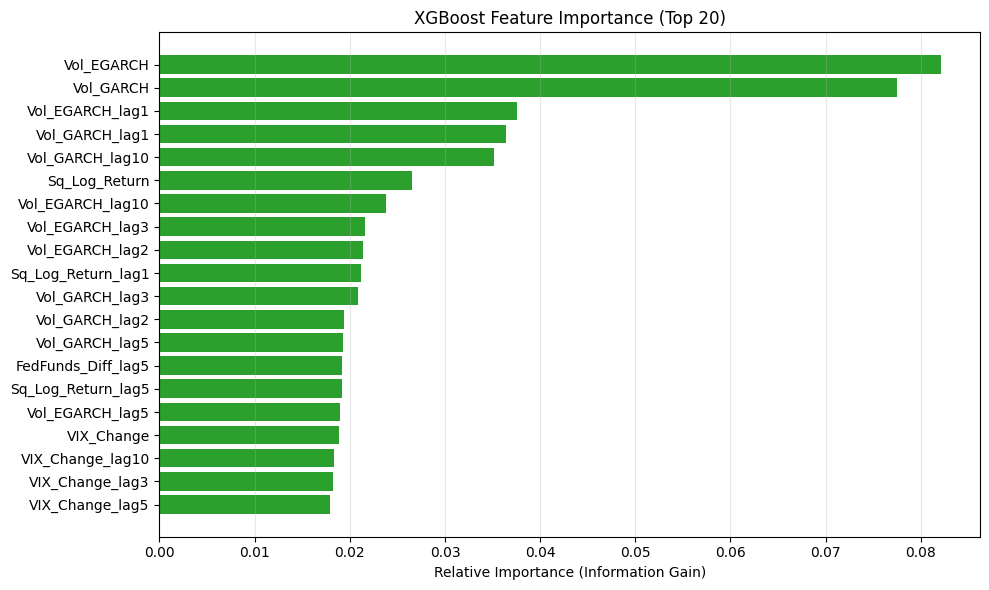

In [1]:
# In 03_baseline_xgboost.ipynb
from src import data_loader, features, volatility, regimes, models_xgb

# 1. Core Pipeline
raw_df = data_loader.fetch_raw_data()
stat_df = features.engineer_stationary_features(raw_df)
garch_df = volatility.generate_expanding_garch(stat_df, min_obs=252)
regime_df = regimes.generate_smoothed_targets(garch_df, lower_quant=0.85, upper_quant=0.95, floor=0.0)

# 2. Lag Engineering
cols_to_lag = ['Log_Return', 'Sq_Log_Return', 'Vol_GARCH', 'Vol_EGARCH', 
               'VIX_Change', 'Oil_Change', 'CPI_MoM', 'FedFunds_Diff', 'Term_Spread_Diff']
final_df = features.create_lags(regime_df, feature_cols=cols_to_lag)

# 3. Run the Walk-Forward Validation (4 splits = 20% chunks)
final_model, feature_names = models_xgb.train_xgb_walk_forward(final_df, n_splits=4)

# 4. Look at feature importance from the most mature model fold
models_xgb.plot_feature_importance(final_model, feature_names)

In [1]:
# 03_baseline_xgboost.ipynb
from src import data_loader, features, volatility, regimes, models_xgb
import pandas as pd

# 1. Standard Data Ingest & Math
raw_df = data_loader.fetch_raw_data()
stat_df = features.engineer_stationary_features(raw_df)
garch_df = volatility.generate_expanding_garch(stat_df)

# 2. Generate the 4-State HMM
print("\n--- Generating HMM Targets ---")
hmm_4_df = regimes.generate_hmm_targets(garch_df, feature_cols=['Log_Return', 'Vol_EGARCH'], n_components=4)

# 3. Safe Merge & Mapping to 3 ML Classes
master_df = garch_df.copy()
master_df['Target_HMM'] = hmm_4_df['Target_HMM']
master_df = master_df.dropna(subset=['Target_HMM'])

# Collapse the two lowest volatility states into Class 0 (Calm)
mapping_dict = {
    0: 0,  # Dead Calm -> Calm
    1: 0,  # Normal -> Calm
    2: 1,  # Elevated
    3: 2   # Shock
}
master_df['Target_HMM_ML'] = master_df['Target_HMM'].map(mapping_dict).astype(int)
master_df = master_df.drop('Target_HMM', axis=1)

# 4. Lag Engineering for XGBoost
cols_to_lag = [
    'Log_Return', 'Sq_Log_Return', 'Vol_GARCH', 'Vol_EGARCH', 
    'VIX_Change', 'Oil_Change', 'CPI_MoM', 'FedFunds_Diff', 'Term_Spread_Diff'
]
final_df = features.create_lags(master_df, feature_cols=cols_to_lag)

# 5. Walk-Forward Validation
# We pass our newly mapped HMM column as the target
final_model, feature_names = models_xgb.train_xgb_walk_forward(
    df=final_df, 
    target_col='Target_HMM_ML', 
    n_splits=4
)

Loading cached raw data from /home/solidburak/Documents/Codes/Python/Thesis/data/raw/master_raw_data.parquet...
Engineering stationary features...
Stationary transformation complete. Raw columns purged.
Generating Industry Standard GARCH & EGARCH (Window: 252, Refit: 21 days)...


Out-of-sample GARCH/EGARCH generation complete.

--- Generating HMM Targets ---

--- HMM Generation Process ---


HMM State 0 Average Volatility: 0.0091
HMM State 1 Average Volatility: 5.3124
HMM State 2 Average Volatility: 28.3234
HMM State 3 Average Volatility: 0.0343
Mapping Order (Lowest Vol to Highest Vol): [0, 3, 1, 2]
HMM Target generation complete. Shape: (6227, 1)

Generating lag features for: [1, 2, 3, 5, 10] days...
Starting expanding-window Walk-Forward Validation (4 splits)...

--- Fold 1 ---
  Training on index 0 to 1243 (Samples: 1243)
  Testing on index 1243 to 2486 (Samples: 1243)


ValueError: Number of classes, 2, does not match size of target_names, 3. Try specifying the labels parameter

In [ ]:
# 6. Plot the Final Feature Importance
models_xgb.plot_feature_importance(final_model, feature_names)